
# Least Squares Polynomial Fitting

## Overview
This notebook demonstrates polynomial curve fitting using the **Least Squares Method** and the **Normal Equations** approach.

The accompanying Python module `find_coffecient.py` constructs and solves the normal-equation system

$$
A\mathbf{a}=\mathbf{d}
$$

where the coefficient vector is

$$
\mathbf{a}=[a_0,a_1,\dots,a_n]^T.
$$

The fitted polynomial is

$$
P(x)=a_0+a_1x+a_2x^2+\cdots+a_nx^n.
$$

The objective is to minimize the sum of squared residuals

$$
S=\sum_{i=1}^{m}(y_i-P(x_i))^2.
$$

The notebook studies:
1. First-degree (linear) fitting.
2. Second-degree (quadratic) fitting.
3. Third-degree (cubic) fitting.

For each dataset, the raw observations are visualized and then compared with the fitted polynomial curve.



## Dataset 1 – Linear Model

The first dataset is approximated using a first-degree polynomial:

$$
P_1(x)=a_0+a_1x.
$$

The scatter plot below shows the original observations before fitting.


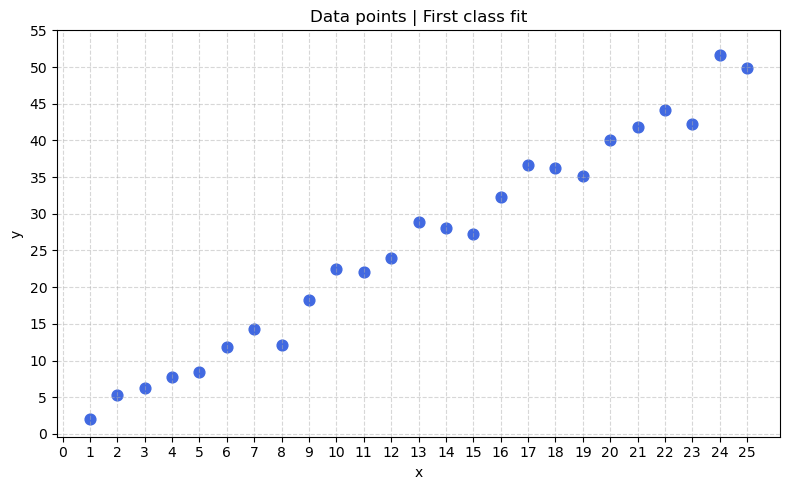

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from find_coffecient import *

data_deg1 = [
    (1, 2.1), (2, 5.3), (3, 6.2), (4, 7.8), (5, 8.4),  
    (6, 11.9), (7, 14.3), (8, 12.1), (9, 18.2), (10, 22.5), 
    (11, 22.1), (12, 24.0), (13, 28.9), (14, 28.1), (15, 27.2),
    (16, 32.3), (17, 36.7), (18, 36.2), (19, 35.1), (20, 40.1), 
    (21, 41.8), (22, 44.2), (23, 42.3), (24, 51.6), (25, 49.8) 
]
x_1 = [p[0] for p in data_deg1]
y_1 = [p[1] for p in data_deg1]

plt.figure(figsize=(8, 5))
plt.scatter(x_1, y_1, color='royalblue', s=60)
plt.title('Data points | First class fit')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(np.arange(0, 26, 1))
plt.yticks(np.arange(0, 56, 5)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Linear Fit Result

The fitted line is obtained by minimizing the least-squares error.

$$
P_1(x)=a_0+a_1x
$$

The red line represents the estimated model and the reported error is the mean absolute fitting error.


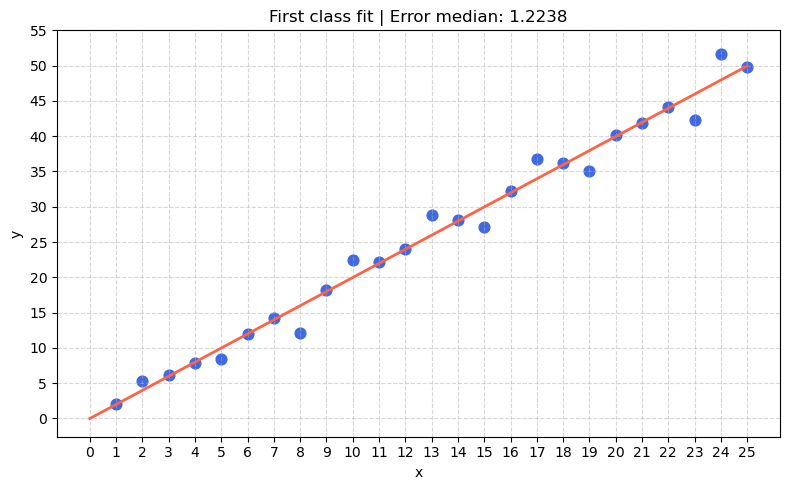

In [8]:
from numpy.polynomial import Polynomial

cofficients = find_coff_poly(1, data_deg1)
p = Polynomial(cofficients)
error_median = sum(abs(p(pt[0]) - pt[1]) for pt in data_deg1) / len(data_deg1)

plt.figure(figsize=(8, 5))
plt.scatter(x_1, y_1, color='royalblue', s=60)
plt.plot([0, 25], [p(0), p(25)], color='tomato', linewidth=2)
plt.title(f'First class fit | Error median: {error_median:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(np.arange(0, 26, 1))
plt.yticks(np.arange(0, 56, 5)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Dataset 2 – Quadratic Model

The second dataset exhibits nonlinear growth, therefore a quadratic polynomial is considered:

$$
P_2(x)=a_0+a_1x+a_2x^2.
$$

The following figure shows the raw data.


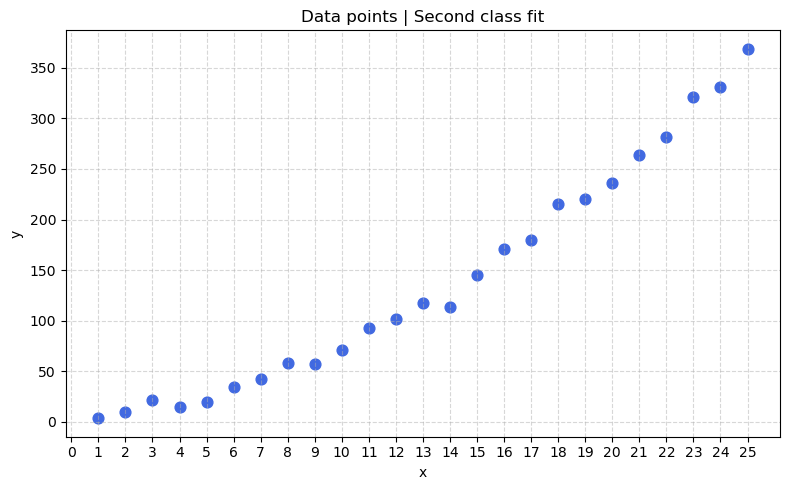

In [9]:
data_deg2 = [
    (1, 3.6), (2, 9.4), (3, 21.8), (4, 15.1), (5, 19.9),
    (6, 34.2), (7, 42.3), (8, 58.2), (9, 56.8), (10, 71.1),
    (11, 92.7), (12, 101.5), (13, 117.6), (14, 113.1), (15, 145.2),
    (16, 171.2), (17, 179.7), (18, 215.3), (19, 219.8), (20, 236.4),
    (21, 263.6), (22, 281.1), (23, 321.2), (24, 331.2), (25, 368.7)
]
x_2 = [p[0] for p in data_deg2]
y_2 = [p[1] for p in data_deg2]

plt.figure(figsize=(8, 5))
plt.scatter(x_2, y_2, color='royalblue', s=60)
plt.title('Data points | Second class fit')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(np.arange(0, 26, 1))
plt.yticks(np.arange(0, 365, 50)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Quadratic Fit Result

The quadratic curve captures the accelerating trend of the observations.

$$
P_2(x)=a_0+a_1x+a_2x^2
$$

The smooth curve is generated from the estimated coefficients.


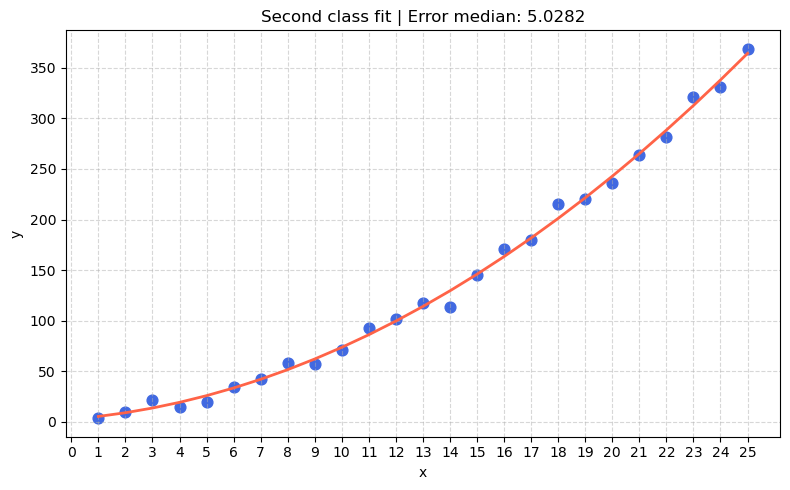

In [10]:
cofficients_2 = find_coff_poly(2, data_deg2)
p_2 = Polynomial(cofficients_2)
error_median_2 = sum(abs(p_2(pt[0]) - pt[1]) for pt in data_deg2) / len(data_deg2)

x_smooth_1 = [i for i in range(1, 26)]
y_smooth_1 = [p_2(xi) for xi in x_smooth_1]

plt.figure(figsize=(8, 5))
plt.scatter(x_2, y_2, color='royalblue', s=60)
plt.plot(x_smooth_1, y_smooth_1, color='tomato', linewidth=2)
plt.title(f'Second class fit | Error median: {error_median_2:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(np.arange(0, 26, 1))
plt.yticks(np.arange(0, 370, 50)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Dataset 3 – Cubic Model

The third dataset changes direction and cannot be modeled adequately by a straight line.

A cubic polynomial is therefore used:

$$
P_3(x)=a_0+a_1x+a_2x^2+a_3x^3.
$$

The scatter plot below displays the observations.


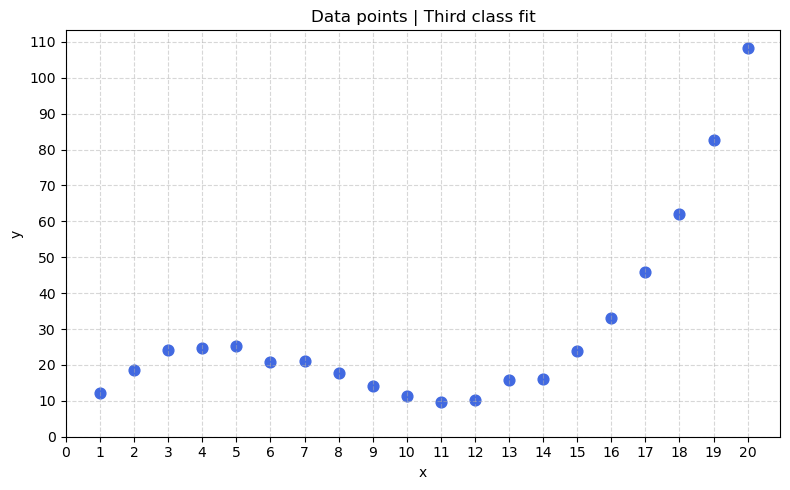

In [12]:
data_deg3 = [
    (1, 12.3), (2, 18.7), (3, 24.1), (4, 24.8), (5, 25.3),  
    (6, 20.9), (7, 21.2), (8, 17.8), (9, 14.1), (10, 11.3),  
    (11, 9.8), (12, 10.2), (13, 15.9), (14, 16.1), (15, 23.8), 
    (16, 33.2), (17, 45.9), (18, 62.1), (19, 82.7), (20, 108.3),
]

x_3 = [p[0] for p in data_deg3]
y_3 = [p[1] for p in data_deg3]

plt.figure(figsize=(8, 5))
plt.scatter(x_3, y_3, color='royalblue', s=60)
plt.title('Data points | Third class fit')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 111, 10)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Cubic Fit Result

The cubic model provides enough flexibility to represent turning points in the data.

$$
P_3(x)=a_0+a_1x+a_2x^2+a_3x^3.
$$

The fitted curve is compared with the measured observations.


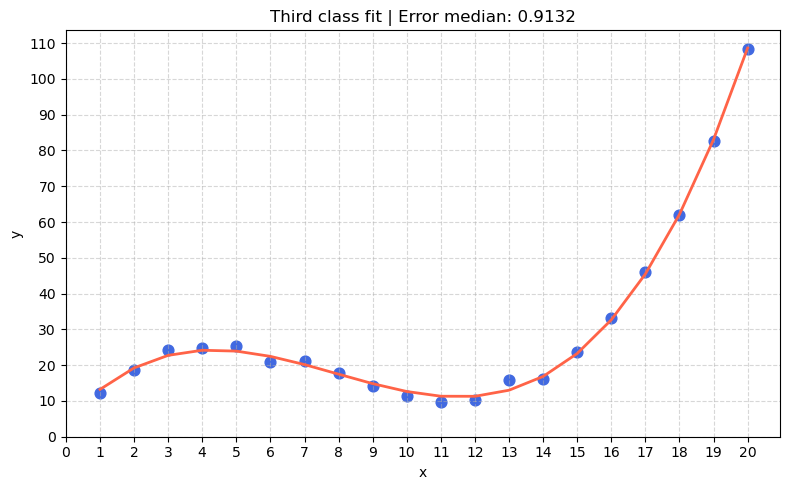

In [13]:
cofficients_3 = find_coff_poly(3, data_deg3)
p_3 = Polynomial(cofficients_3)
error_median_3 = sum(abs(p_3(pt[0]) - pt[1]) for pt in data_deg3) / len(data_deg3)

x_smooth = [i for i in range(1, 21)]
y_smooth = [p_3(xi) for xi in x_smooth]

plt.figure(figsize=(8, 5))
plt.scatter(x_3, y_3, color='royalblue', s=60)
plt.plot(x_smooth, y_smooth, color='tomato', linewidth=2)
plt.title(f'Third class fit | Error median: {error_median_3:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 111, 10)) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()